# Task I: Quantum Computing


**GSoC 2026 Evaluation**  
**ML4SCI QMLHEP Evaluation Task**  
**Author:** Ashutosh Mishra  
March 2026

---

### Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | Setup | Dependencies and version check |
| 2 | Basic 5-Qubit Circuit | Hadamard, CNOT chain, SWAP, and RX gates |
| 3 | SWAP Test | Fidelity measurement between two 2-qubit quantum states |

---

## 1. Setup

In [1]:
# Install dependencies (uncomment if needed)
# !pip install pennylane matplotlib

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.44.1


---

## 2. Basic 5-Qubit Circuit

A 5-qubit circuit applying a sequence of standard quantum gates. The table below summarizes each gate and its physical effect on the qubit state.

| Gate | Operation | Physical effect |
|------|-----------|-----------------|
| **H** | Hadamard | Maps $\|0\rangle \to \|+\rangle = \frac{1}{\sqrt{2}}(\|0\rangle + \|1\rangle)$. Rotates the Bloch vector from the Z-axis to the X-axis. |
| **CNOT** | Controlled-NOT | Flips the target qubit conditioned on the control being $\|1\rangle$. Primary two-qubit entangling gate. |
| **SWAP** | Swap | Exchanges the quantum states of two qubits. Decomposes into three consecutive CNOTs. |
| **RX($\theta$)** | X-rotation | $RX(\theta) = e^{-i\theta X/2}$. At $\theta = \pi/2$: maps $\|0\rangle \to \frac{1}{\sqrt{2}}(\|0\rangle - i\|1\rangle)$. |

### 2.1 Circuit Construction

Gate sequence applied to the register:
1. Hadamard on all 5 qubits: creates a uniform superposition across $2^5 = 32$ basis states
2. CNOT chain: $(0,1), (1,2), (2,3), (3,4)$: propagates entanglement down the register
3. SWAP on qubits 0 and 4
4. $RX(\pi/2)$ on qubit 2

In [2]:
n_qubits = 5
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def basic_circuit():
    """5-qubit circuit with H, CNOT chain, SWAP, and RX gates."""
    for q in range(n_qubits):
        qml.Hadamard(wires=q)

    for q in range(n_qubits - 1):
        qml.CNOT(wires=[q, q + 1])

    qml.SWAP(wires=[0, 4])
    qml.RX(np.pi / 2, wires=2)

    return qml.state()

state = basic_circuit()
print(f"State vector: {len(state)} amplitudes (2^{n_qubits})")
print(f"\nFirst 8 basis-state amplitudes:")
for i in range(8):
    print(f"  |{i:05b}⟩ : {state[i]:.4f}")

State vector: 32 amplitudes (2^5)

First 8 basis-state amplitudes:
  |00000⟩ : 0.1250-0.1250j
  |00001⟩ : 0.1250-0.1250j
  |00010⟩ : 0.1250-0.1250j
  |00011⟩ : 0.1250-0.1250j
  |00100⟩ : 0.1250-0.1250j
  |00101⟩ : 0.1250-0.1250j
  |00110⟩ : 0.1250-0.1250j
  |00111⟩ : 0.1250-0.1250j


### 2.2 Circuit Diagram

/var/folders/xq/y8br4hqn3t93g5jccdygyqdh0000gn/T/ipykernel_11282/4187524017.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


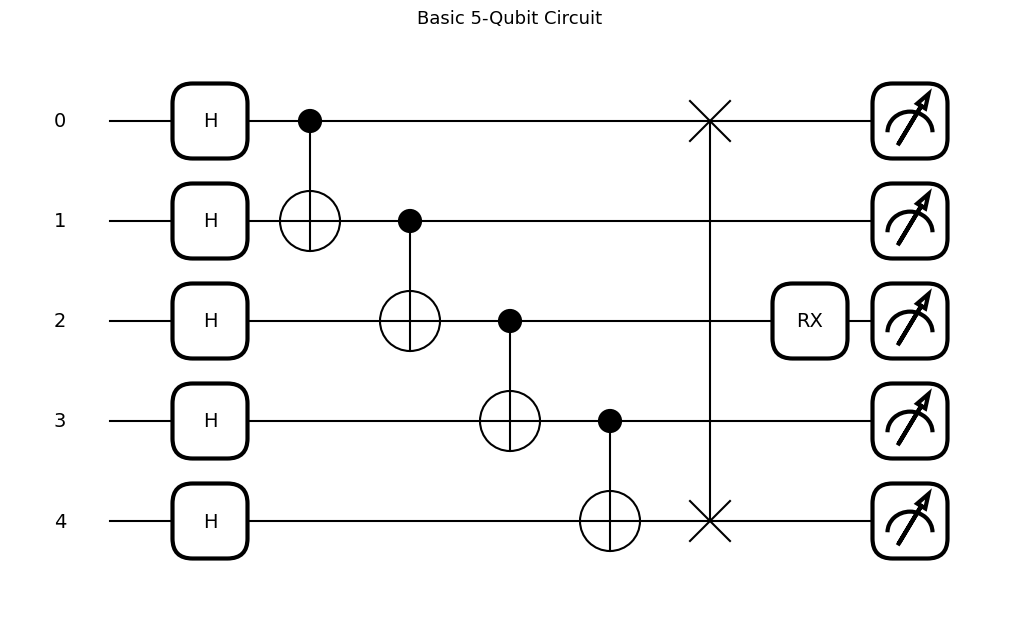

0: ──H─╭●──────────╭SWAP───────────┤  State
1: ──H─╰X─╭●───────│───────────────┤  State
2: ──H────╰X─╭●────│──────RX(1.57)─┤  State
3: ──H───────╰X─╭●─│───────────────┤  State
4: ──H──────────╰X─╰SWAP───────────┤  State


In [3]:
fig, ax = qml.draw_mpl(basic_circuit)()
fig.suptitle("Basic 5-Qubit Circuit", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(qml.draw(basic_circuit)())

### 2.3 Measurement Analysis

Measurement probabilities computed directly from the state vector: $P(\|x\rangle) = |\langle x | \psi \rangle|^2$.

In [4]:
probs = np.abs(state) ** 2

ranked = np.argsort(probs)[::-1][:10]
print("Top 10 measurement outcomes:")
for idx in ranked:
    print(f"  |{idx:05b}⟩  p = {probs[idx]:.6f}")

print(f"\nTotal probability: {np.sum(probs):.10f}")

Top 10 measurement outcomes:
  |11111⟩  p = 0.031250
  |11110⟩  p = 0.031250
  |00001⟩  p = 0.031250
  |00010⟩  p = 0.031250
  |00011⟩  p = 0.031250
  |00100⟩  p = 0.031250
  |00101⟩  p = 0.031250
  |00110⟩  p = 0.031250
  |00111⟩  p = 0.031250
  |01000⟩  p = 0.031250

Total probability: 1.0000000000


---

## 3. SWAP Test

The SWAP test measures the squared overlap $|\langle\psi|\phi\rangle|^2$ between two quantum states without full state tomography.

**Protocol:** An ancilla qubit in $|0\rangle$ is placed in superposition via Hadamard, controlled-SWAP gates conditionally exchange the two state registers, and a second Hadamard on the ancilla produces interference. Measuring the ancilla encodes the fidelity:

$$P(\text{ancilla} = |0\rangle) = \frac{1 + |\langle\psi|\phi\rangle|^2}{2} \quad \Longrightarrow \quad |\langle\psi|\phi\rangle|^2 = 2\,P(|0\rangle) - 1$$

Identical states yield $P(|0\rangle) = 1$; orthogonal states yield $P(|0\rangle) = 0.5$.

### 3.1 Circuit Implementation

**Qubit layout** (5 qubits total):

| Wire | Role | State preparation |
|------|------|-------------------|
| 0 | Ancilla | — |
| 1, 2 | Register A ($\|\psi\rangle$) | $H\|0\rangle \otimes RX(\pi/3)\|0\rangle$ |
| 3, 4 | Register B ($\|\phi\rangle$) | $H\|0\rangle \otimes H\|0\rangle$ |

The controlled-SWAP across 2-qubit registers decomposes into two CSWAP (Fredkin) gates: one swapping $(q_1, q_3)$ and one swapping $(q_2, q_4)$, both conditioned on the ancilla.

In [5]:
ANCILLA = 0
dev_swap = qml.device("default.qubit", wires=5)

@qml.qnode(dev_swap)
def swap_test():
    """SWAP test between two 2-qubit registers."""
    # Register A: |ψ⟩
    qml.Hadamard(wires=1)
    qml.RX(np.pi / 3, wires=2)

    # Register B: |φ⟩
    qml.Hadamard(wires=3)
    qml.Hadamard(wires=4)

    # SWAP test protocol
    qml.Hadamard(wires=ANCILLA)
    qml.CSWAP(wires=[ANCILLA, 1, 3])  # swap q1 ↔ q3
    qml.CSWAP(wires=[ANCILLA, 2, 4])  # swap q2 ↔ q4
    qml.Hadamard(wires=ANCILLA)

    return qml.probs(wires=ANCILLA)

result = swap_test()
print(f"P(ancilla = |0⟩) = {result[0]:.6f}")
print(f"P(ancilla = |1⟩) = {result[1]:.6f}")

P(ancilla = |0⟩) = 0.750000
P(ancilla = |1⟩) = 0.250000


### 3.2 Fidelity Verification

The fidelity extracted from the SWAP test is cross-checked against an analytical calculation using the tensor-product structure of the two register states.

In [6]:
# Fidelity from SWAP test
fidelity = 2 * result[0] - 1
print(f"SWAP test fidelity:  |⟨ψ|φ⟩|² = {fidelity:.6f}")

# Analytical verification
# |ψ⟩ = H|0⟩ ⊗ RX(π/3)|0⟩,   |φ⟩ = H|0⟩ ⊗ H|0⟩
h0 = np.array([1, 1]) / np.sqrt(2)                                # H|0⟩
rx0 = np.array([np.cos(np.pi / 6), -1j * np.sin(np.pi / 6)])     # RX(π/3)|0⟩

psi = np.kron(h0, rx0)
phi = np.kron(h0, h0)

overlap_sq = np.abs(np.vdot(psi, phi)) ** 2
print(f"Analytical fidelity: |⟨ψ|φ⟩|² = {overlap_sq:.6f}")
print(f"\nResults match: {np.isclose(fidelity, overlap_sq)}")

SWAP test fidelity:  |⟨ψ|φ⟩|² = 0.500000
Analytical fidelity: |⟨ψ|φ⟩|² = 0.500000

Results match: True


### 3.3 Circuit Diagram

/var/folders/xq/y8br4hqn3t93g5jccdygyqdh0000gn/T/ipykernel_11282/1596854181.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


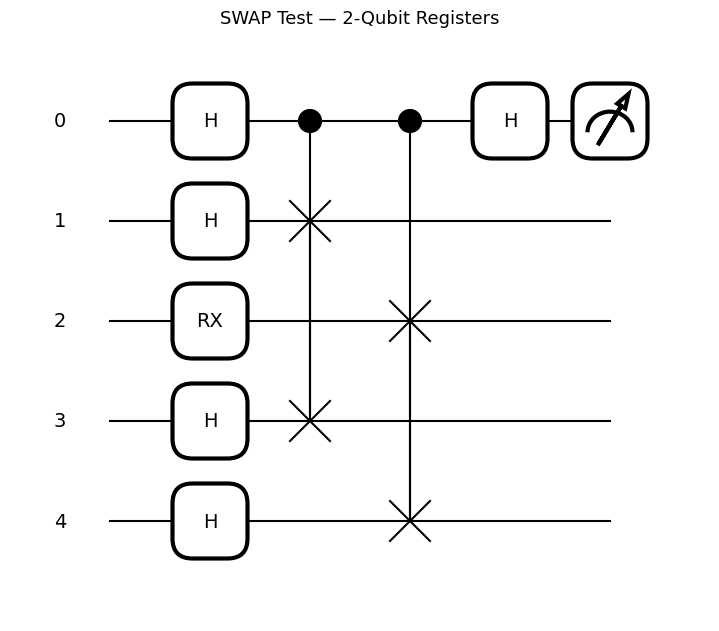

0: ──H────────╭●────╭●─────H─┤  Probs
1: ──H────────├SWAP─│────────┤       
2: ──RX(1.05)─│─────├SWAP────┤       
3: ──H────────╰SWAP─│────────┤       
4: ──H──────────────╰SWAP────┤       


In [7]:
fig, ax = qml.draw_mpl(swap_test)()
fig.suptitle("SWAP Test — 2-Qubit Registers", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(qml.draw(swap_test)())

### 3.4 Discussion

The measured fidelity $|\langle\psi|\phi\rangle|^2 = 0.5$ reflects partial overlap between the two registers. Both registers share the same first-qubit state ($|+\rangle$ from the Hadamard), so their first-qubit overlap is unity. The difference lies entirely in the second qubit: register A has $RX(\pi/3)|0\rangle = \cos(\pi/6)|0\rangle - i\sin(\pi/6)|1\rangle$, while register B has $H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$. These differ in both amplitude distribution and relative phase, giving a single-qubit overlap of $|\langle RX(\pi/3)0 | + \rangle|^2 = 1/2$. The total fidelity factorizes as $1 \times 1/2 = 0.5$, consistent with the circuit output.

The SWAP test is a core primitive in quantum kernel methods and contrastive representation learning (cf. Task VI), where it provides a hardware-efficient inner-product estimation without requiring classical access to the full state vectors.